In [1]:
import sys
sys.path.append('..')  # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from scipy.stats import ks_2samp

import lightgbm as lgb
import shap
import optuna
import joblib

from src.features.build_features import build_features

pd.set_option('display.max_columns', 200)
sns.set_style("whitegrid")

DATA_PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Setup complete")

Setup complete


In [2]:
train = pd.read_parquet(DATA_PROCESSED / "train.parquet")
val   = pd.read_parquet(DATA_PROCESSED / "val.parquet")
test  = pd.read_parquet(DATA_PROCESSED / "test.parquet")

train = build_features(train)
val   = build_features(val)
test  = build_features(test)

In [3]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
for df in [train, val, test]:
    for col in cat_cols:
        df[col] = df[col].astype('category')

feature_cols = [c for c in train.columns if c not in ['TARGET', 'SK_ID_CURR']]

C:\Users\rohit\AppData\Local\Temp\ipykernel_15392\2244915879.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns.tolist()


In [4]:
X_train, y_train = train[feature_cols], train['TARGET']
X_val,   y_val   = val[feature_cols],   val['TARGET']
X_test,  y_test  = test[feature_cols],  test['TARGET']
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (215257, 135), X_val: (46127, 135), X_test: (46127, 135)


In [6]:
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': 5,
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'is_unbalance': True,
        'verbose': -1,
        'random_state': 42
    }

    lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cat_cols)
    lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train, categorical_feature=cat_cols)

    model = lgb.train(
        params, lgb_train,
        num_boost_round=2000,
        valid_sets=[lgb_val],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    return model.best_score['valid_0']['auc']

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest val AUC: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best val AUC: 0.7724
Best params:
  learning_rate: 0.010033224249656896
  num_leaves: 55
  max_depth: 9
  min_child_samples: 130
  feature_fraction: 0.6974970587599799
  bagging_fraction: 0.7756436806759427
  reg_alpha: 0.029265961527112718
  reg_lambda: 0.3769940070122927


In [7]:
best_params = study.best_params
best_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'bagging_freq': 5,
    'is_unbalance': True,
    'verbose': -1,
    'random_state': 42
})

lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cat_cols)
lgb_val   = lgb.Dataset(X_val, y_val, reference=lgb_train, categorical_feature=cat_cols)

final_model = lgb.train(
    best_params, lgb_train,
    num_boost_round=5000,                       # higher cap since lr is low
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
)

print(f"Best iteration: {final_model.best_iteration}")

Training until validation scores don't improve for 100 rounds
[500]	train's auc: 0.816162	val's auc: 0.769289
[1000]	train's auc: 0.850957	val's auc: 0.772326
Early stopping, best iteration is:
[946]	train's auc: 0.847696	val's auc: 0.772375
Best iteration: 946


In [8]:
def eval_from_preds(y_true, y_pred, name):
    auc = roc_auc_score(y_true, y_pred)
    ks, _ = ks_2samp(y_pred[y_true==1], y_pred[y_true==0])
    brier = brier_score_loss(y_true, y_pred)
    print(f"{name:8s} | AUC: {auc:.4f} | KS: {ks:.4f} | Brier: {brier:.4f}")
    return auc, ks, brier

pred_train = final_model.predict(X_train)
pred_val   = final_model.predict(X_val)
pred_test  = final_model.predict(X_test)

print("Tuned LightGBM (raw probabilities):")
eval_from_preds(y_train, pred_train, "train")
eval_from_preds(y_val,   pred_val,   "val")
eval_from_preds(y_test,  pred_test,  "test")

Tuned LightGBM (raw probabilities):
train    | AUC: 0.8477 | KS: 0.5366 | Brier: 0.1687
val      | AUC: 0.7724 | KS: 0.4176 | Brier: 0.1755
test     | AUC: 0.7672 | KS: 0.3978 | Brier: 0.1782


(0.7672284313665559, np.float64(0.3977725775328837), 0.1782133004658168)

In [9]:
from sklearn.isotonic import IsotonicRegression

iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(pred_val, y_val)  # fit on VALIDATION only — never train, never test

pred_train_cal = iso_reg.predict(pred_train)
pred_val_cal   = iso_reg.predict(pred_val)
pred_test_cal  = iso_reg.predict(pred_test)

print("Calibrated probabilities:")
eval_from_preds(y_train, pred_train_cal, "train")
eval_from_preds(y_val,   pred_val_cal,   "val")
eval_from_preds(y_test,  pred_test_cal,  "test")

Calibrated probabilities:
train    | AUC: 0.8469 | KS: 0.5364 | Brier: 0.0634
val      | AUC: 0.7741 | KS: 0.4176 | Brier: 0.0661
test     | AUC: 0.7662 | KS: 0.3972 | Brier: 0.0664


(0.766233424767505, np.float64(0.3971782902379932), 0.0664210413595284)

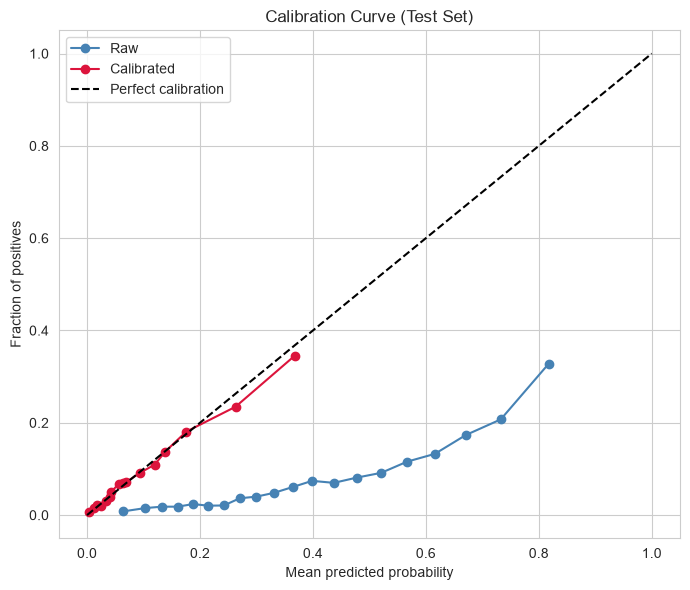

In [10]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

for preds, label, color in [
    (pred_test, 'Raw', 'steelblue'),
    (pred_test_cal, 'Calibrated', 'crimson')
]:
    frac_pos, mean_pred = calibration_curve(y_test, preds, n_bins=20, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=label, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/calibration_curve.png', dpi=100)
plt.show()

## Fairness Correction: Excluding CODE_GENDER

Initial model included CODE_GENDER as a feature. Upon review, this 
violates fair lending regulations (ECOA, FCA). Retraining without 
gender shows the cost of exclusion: test AUC from 0.7672 → 0.7666 
(a 0.0006 drop). This confirms gender was not materially driving 
performance once external credit scores are included.

The following cells retrain the model without CODE_GENDER and 
recompute calibration and SHAP. **The final model state is from 
these cells.**

In [13]:
# Redefine feature_cols to exclude CODE_GENDER
PROTECTED_ATTRS = ['CODE_GENDER']
feature_cols = [c for c in train.columns if c not in ['TARGET', 'SK_ID_CURR'] + PROTECTED_ATTRS]
print(f"Features after exclusion: {len(feature_cols)}")

X_train, y_train = train[feature_cols], train['TARGET']
X_val,   y_val   = val[feature_cols],   val['TARGET']
X_test,  y_test  = test[feature_cols],  test['TARGET']

# Drop CODE_GENDER from categorical list too
cat_cols = [c for c in cat_cols if c not in PROTECTED_ATTRS]

# Retrain with tuned params (no Optuna rerun)
lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cat_cols)
lgb_val   = lgb.Dataset(X_val, y_val, reference=lgb_train, categorical_feature=cat_cols)

final_model = lgb.train(
    best_params, lgb_train,
    num_boost_round=5000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
)

print(f"Best iteration: {final_model.best_iteration}")

# Recompute predictions
pred_train = final_model.predict(X_train)
pred_val   = final_model.predict(X_val)
pred_test  = final_model.predict(X_test)

print("\nRaw probabilities:")
eval_from_preds(y_train, pred_train, "train")
eval_from_preds(y_val,   pred_val,   "val")
eval_from_preds(y_test,  pred_test,  "test")

# Recalibrate
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(pred_val, y_val)

pred_train_cal = iso_reg.predict(pred_train)
pred_val_cal   = iso_reg.predict(pred_val)
pred_test_cal  = iso_reg.predict(pred_test)

print("\nCalibrated probabilities:")
eval_from_preds(y_train, pred_train_cal, "train")
eval_from_preds(y_val,   pred_val_cal,   "val")
eval_from_preds(y_test,  pred_test_cal,  "test")

Features after exclusion: 134
Training until validation scores don't improve for 100 rounds
[500]	train's auc: 0.814532	val's auc: 0.767672
[1000]	train's auc: 0.849333	val's auc: 0.770523
Early stopping, best iteration is:
[1085]	train's auc: 0.854342	val's auc: 0.770609
Best iteration: 1085

Raw probabilities:
train    | AUC: 0.8543 | KS: 0.5495 | Brier: 0.1661
val      | AUC: 0.7706 | KS: 0.4073 | Brier: 0.1741
test     | AUC: 0.7666 | KS: 0.3969 | Brier: 0.1765

Calibrated probabilities:
train    | AUC: 0.8534 | KS: 0.5474 | Brier: 0.0630
val      | AUC: 0.7722 | KS: 0.4073 | Brier: 0.0662
test     | AUC: 0.7661 | KS: 0.3959 | Brier: 0.0665


(0.7661493616360643, np.float64(0.3959104726134808), 0.06647484546042631)

In [14]:
print(f"Feature count: {len(feature_cols)}")   # should be 134
print(f"'CODE_GENDER' in features: {'CODE_GENDER' in feature_cols}")  # should be False

Feature count: 134
'CODE_GENDER' in features: False


In [16]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list of two arrays.
# Index 1 = SHAP values for the positive class (default).
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

print(f"SHAP values shape: {shap_values_pos.shape}")

SHAP values shape: (46127, 134)


c:\Users\rohit\OneDrive\Desktop\Personal Project\credit-risk-decision-engine\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


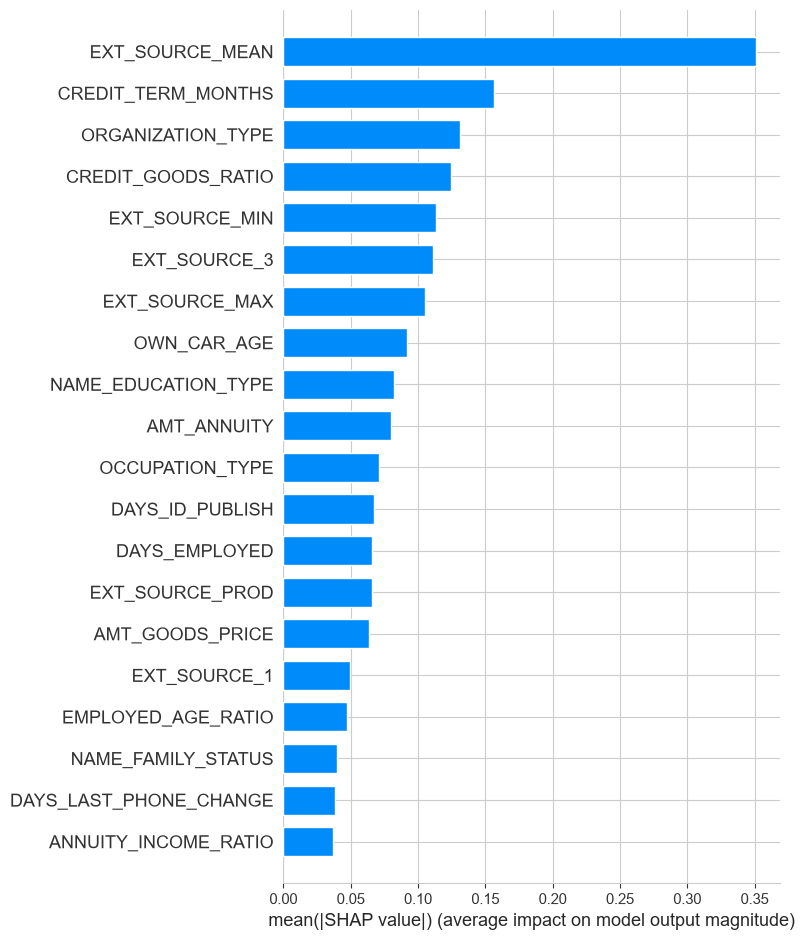

In [17]:
shap.summary_plot(shap_values_pos, X_test, plot_type="bar", max_display=20, show=True)

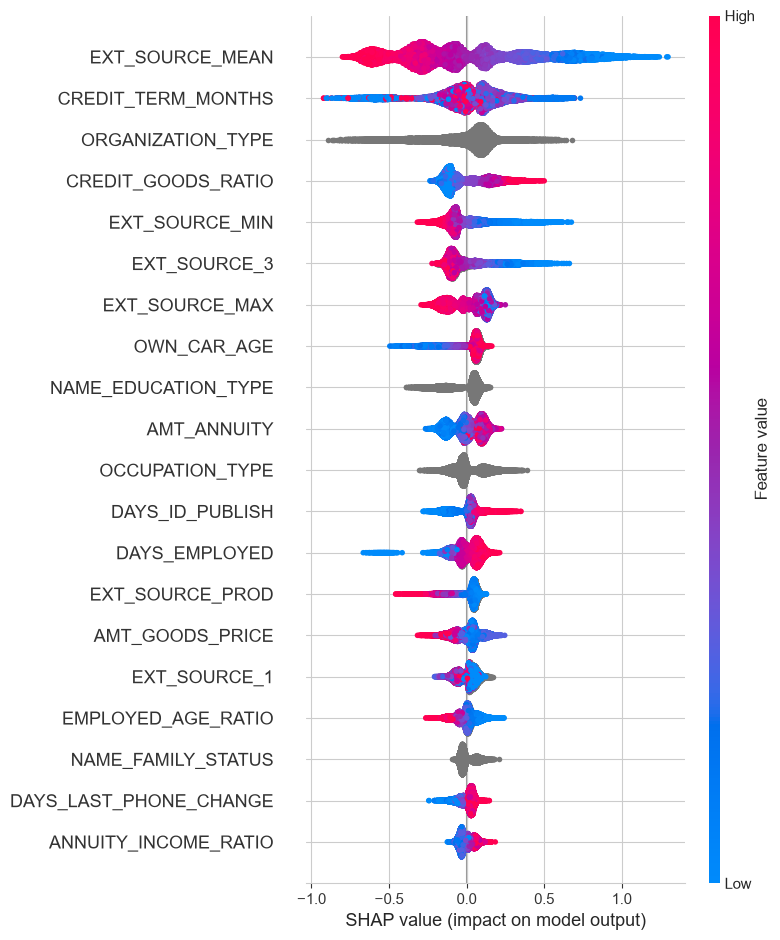

In [18]:
shap.summary_plot(shap_values_pos, X_test, max_display=20, show=True)

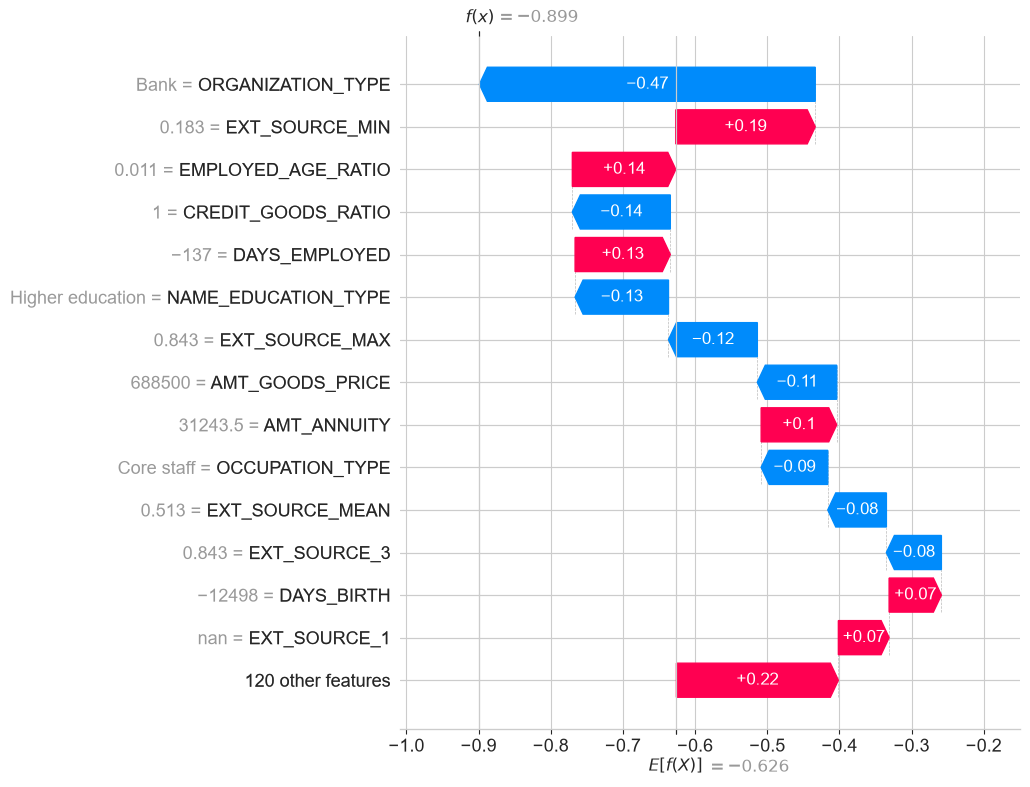

Actual TARGET: 0
Predicted (raw):        0.2893
Predicted (calibrated): 0.0369


In [19]:
sample_idx = 0
base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_pos[sample_idx],
        base_values=base_value,
        data=X_test.iloc[sample_idx].values,
        feature_names=X_test.columns.tolist()
    ),
    max_display=15,
    show=True
)

print(f"Actual TARGET: {y_test.iloc[sample_idx]}")
print(f"Predicted (raw):        {pred_test[sample_idx]:.4f}")
print(f"Predicted (calibrated): {pred_test_cal[sample_idx]:.4f}")

In [20]:
def explain_applicant(idx, top_k=3):
    sv = shap_values_pos[idx]
    features = X_test.iloc[idx]
    top_idx = np.argsort(np.abs(sv))[::-1][:top_k]

    print(f"--- Applicant {idx} ---")
    print(f"Predicted default prob (calibrated): {pred_test_cal[idx]:.4f}")
    print(f"Actual outcome: {'Defaulted' if y_test.iloc[idx] == 1 else 'Repaid'}\n")
    print("Top reason codes:")
    for i in top_idx:
        feature = X_test.columns[i]
        value = features.iloc[i]
        impact = sv[i]
        direction = "↑ risk" if impact > 0 else "↓ risk"
        print(f"  {feature:35s} = {str(value)[:20]:20s} → {direction} ({impact:+.4f})")

for i in [0, 1, 2]:
    explain_applicant(i)
    print()

--- Applicant 0 ---
Predicted default prob (calibrated): 0.0369
Actual outcome: Repaid

Top reason codes:
  ORGANIZATION_TYPE                   = Bank                 → ↓ risk (-0.4654)
  EXT_SOURCE_MIN                      = 0.1826442517794768   → ↑ risk (+0.1932)
  EMPLOYED_AGE_RATIO                  = 0.010961753880620899 → ↑ risk (+0.1434)

--- Applicant 1 ---
Predicted default prob (calibrated): 0.0518
Actual outcome: Repaid

Top reason codes:
  EXT_SOURCE_MEAN                     = 0.34678214667540924  → ↑ risk (+0.5723)
  EXT_SOURCE_MIN                      = 0.0005272652387098   → ↑ risk (+0.2904)
  CREDIT_TERM_MONTHS                  = 23.69562252829674    → ↓ risk (-0.2377)

--- Applicant 2 ---
Predicted default prob (calibrated): 0.2684
Actual outcome: Repaid

Top reason codes:
  EXT_SOURCE_MEAN                     = 0.23471296060353028  → ↑ risk (+0.9666)
  EXT_SOURCE_3                        = 0.0884605646541969   → ↑ risk (+0.3517)
  EXT_SOURCE_MIN                      = 

In [21]:
plt.figure()
shap.summary_plot(shap_values_pos, X_test, max_display=20, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=100, bbox_inches='tight')
plt.close()
print("Saved shap_beeswarm.png")

Saved shap_beeswarm.png


In [22]:
import joblib

final_model.save_model(str(MODELS_DIR / "lgb_tuned.txt"))
joblib.dump(iso_reg, MODELS_DIR / "isotonic_calibrator.pkl")

metadata = {
    'feature_cols': feature_cols,
    'categorical_cols': cat_cols,
    'best_params': best_params,
    'best_iteration': final_model.best_iteration,
    'metrics': {
        'train_auc': float(roc_auc_score(y_train, pred_train)),
        'val_auc':   float(roc_auc_score(y_val, pred_val)),
        'test_auc':  float(roc_auc_score(y_test, pred_test)),
        'test_brier_raw':        float(brier_score_loss(y_test, pred_test)),
        'test_brier_calibrated': float(brier_score_loss(y_test, pred_test_cal)),
    }
}
joblib.dump(metadata, MODELS_DIR / "metadata.pkl")

print("Saved files:")
for f in MODELS_DIR.iterdir():
    print(f"  {f.name}")

Saved files:
  .gitkeep
  isotonic_calibrator.pkl
  lgb_tuned.txt
  lgb_v1.txt
  lr_v1.pkl
  metadata.pkl
